In [ ]:
"""
Część B: Analiza w przesuwanych oknach
Analizę ARMA-GARCH w oknach o długości 100, 200, 500 obserwacji
- Początek okna: ostatnia obserwacja 2018
- Wybór rzędów ARMA na początku każdego roku
- Prognoza 1-krokowa dla każdego okna
- Analiza przypadków poza CI, prawdopodobieństwa spadku, zgodności z rozkładem
"""
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
from scipy import stats
import os
from datetime import datetime

# Utworzenie folderu na wyniki
os.makedirs("B_results", exist_ok=True)

# Ustawienia
CSV_FILE = "wig20_d_part_b.csv"
DATE_COL = "Data"
CLOSE_COL = "Zamkniecie"
P_MAX = 3
Q_MAX = 3
WINDOW_SIZES = [100, 200, 500]

# Wczytanie danych
df = pd.read_csv(CSV_FILE, parse_dates=[DATE_COL], dayfirst=True)
df[DATE_COL] = df[DATE_COL].apply(pd.to_datetime)
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df[[DATE_COL, CLOSE_COL]].dropna()

# Log return w procentach
df['logret'] = 100.0 * np.log(df[CLOSE_COL].astype(float) / df[CLOSE_COL].astype(float).shift(1))
df = df.dropna().reset_index(drop=True)

print(f"Zakres danych: {df[DATE_COL].min()} do {df[DATE_COL].max()}")
print(f"Liczba obserwacji: {len(df)}")

# Znajdź indeks ostatniej obserwacji 2018
end_2018_idx = df[df[DATE_COL].dt.year == 2018].index[-1]
print(f"Ostatnia obserwacja 2018: {df.loc[end_2018_idx, DATE_COL]}, indeks: {end_2018_idx}")

# Modele GARCH i rozkłady
vol_models = {
    "GARCH": {"vol": "Garch", "o": 0},
    "EGARCH": {"vol": "EGARCH", "o": 0},
    "GJR-GARCH": {"vol": "Garch", "o": 1}
}
dists = {"normal": "normal", "t": "t", "skewt": "skewt"}

def select_arma_order(series, p_max=3, q_max=3):
    """Wybiera optymalny model ARMA według AIC"""
    best_aic = np.inf
    best_order = (0, 0)
    for p, q in itertools.product(range(p_max+1), range(q_max+1)):
        m = ARIMA(series, order=(p, 0, q))
        res = m.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = (p, q)
    return best_order, best_aic

def ljung_box_p(series, lags=10):
    """Ljung-Box test p-value"""
    lb = acorr_ljungbox(series, lags=[lags], return_df=True)
    return float(lb['lb_pvalue'].iloc[0])

def jarque_bera_test(series):
    """Test Jarque-Bera na normalność"""
    jb_stat, jb_pval = stats.jarque_bera(series)
    return float(jb_pval)

def fit_garch_model(train_data, p_best, q_best, vol_name, vol_spec, dist_name, dist_code):
    """Dopasowanie modelu GARCH i prognoza"""
    try:
        # Prawidłowo skonfiguruj model AR
        if p_best > 0:
            am = arch_model(train_data,
                            mean='AR',
                            lags=p_best,
                            vol=vol_spec['vol'],
                            p=1, o=vol_spec['o'], q=1,
                            dist=dist_code)
        else:
            # Jeśli p=0, model bez składnika AR (tylko stała)
            am = arch_model(train_data,
                            mean='Constant',
                            vol=vol_spec['vol'],
                            p=1, o=vol_spec['o'], q=1,
                            dist=dist_code)
        fit = am.fit(disp='off', show_warning=False)

        # Prognoza 1-step ahead
        fcast = fit.forecast(horizon=1, reindex=False)

        # Warunkowa średnia
        try:
            cond_mean = float(fcast.mean.iloc[-1, 0])
        except Exception as e:
            # Brak fcast.mean - obliczamy ręcznie z parametrów
            print(f"Uwaga: Brak fcast.mean, obliczanie z parametrów: {e}")
            params = fit.params.to_dict()
            mu = params.get('mu', 0.0)
            cond_mean = mu
            if p_best > 0:
                ar_terms = [params.get(f'ar.L{i}', 0.0) for i in range(1, p_best+1)]
                last_vals = train_data.values[-p_best:][::-1]
                cond_mean += sum(a * v for a, v in zip(ar_terms, last_vals))

        cond_var = float(fcast.variance.iloc[-1, 0])
        cond_std = np.sqrt(cond_var)

        # Przedział ufności
        dist_obj = fit.model.distribution
        if dist_obj.num_params == 0:
            dist_params = []
        else:
            dist_params = fit.params[-dist_obj.num_params:]

        q_lower = dist_obj.ppf(0.025, parameters=dist_params)
        q_upper = dist_obj.ppf(0.975, parameters=dist_params)
        ci_lower = cond_mean + cond_std * q_lower
        ci_upper = cond_mean + cond_std * q_upper

        # P(next < 0)
        z0 = (0.0 - cond_mean) / cond_std if cond_std > 0 else 0
        p_neg = float(dist_obj.cdf(z0, parameters=dist_params))

        # Diagnostyka
        std_resid = fit.std_resid
        lb_resid_p = ljung_box_p(std_resid, lags=10)
        lb_sqresid_p = ljung_box_p(std_resid**2, lags=10)
        jb_pval = jarque_bera_test(std_resid)

        return {
            'success': True,
            'fit': fit,
            'cond_mean': cond_mean,
            'cond_var': cond_var,
            'cond_std': cond_std,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'p_neg': p_neg,
            'lb_resid_p': lb_resid_p,
            'lb_sqresid_p': lb_sqresid_p,
            'jb_pval': jb_pval,
            'aic': fit.aic,
            'bic': fit.bic,
            'std_resid': std_resid
        }
    except Exception as e:
        print(f"Error fitting GARCH model: {e}")
        return {'success': False, 'error': str(e)}

# Główna pętla analizy
all_results = []
arma_selections = []

for window_size in WINDOW_SIZES:
    print(f"\n{'='*80}")
    print(f"Analiza dla okna {window_size} obserwacji")
    print(f"{'='*80}")

    # Początek: koniec okna na ostatniej obserwacji 2018
    start_idx = end_2018_idx - window_size + 1

    if start_idx < 0:
        print(f"Za mało danych dla okna {window_size}")
        continue

    # Aktualnie wybrane rzędy ARMA
    current_p, current_q = 0, 0
    current_year = None

    # Przesuwanie okna
    window_num = 0
    for end_idx in range(end_2018_idx, len(df)-1):
        start_idx = end_idx - window_size + 1

        if start_idx < 0:
            break

        window_data = df.iloc[start_idx:end_idx+1].copy()
        train_series = window_data['logret'].copy()

        forecast_date = df.loc[end_idx + 1, DATE_COL]
        real_next = float(df.loc[end_idx + 1, 'logret'])

        # Sprawdź, czy nowy rok -> wybierz na nowo ARMA
        window_year = df.loc[end_idx, DATE_COL].year
        if window_year != current_year:
            current_order, current_aic = select_arma_order(train_series, P_MAX, Q_MAX)
            current_year = window_year
            arma_selections.append({
                'window_size': window_size,
                'year': window_year,
                'date': df.loc[end_idx, DATE_COL],
                'p': current_order[0],
                'q': current_order[1]
            })
            print(f"  Rok {window_year}: wybrano ARMA({current_order[0]},{current_order[1]}) z AIC {current_aic:.2f}")

        # Dopasuj modele dla wszystkich kombinacji
        for vol_name, vol_spec in vol_models.items():
            for dist_name, dist_code in dists.items():
                result = fit_garch_model(train_series, current_order[0], current_order[1],
                                        vol_name, vol_spec, dist_name, dist_code)

                if result['success']:
                    in_ci = result['ci_lower'] <= real_next <= result['ci_upper']
                    predicted_neg = result['p_neg'] > 0.5
                    actual_neg = real_next < 0

                    record = {
                        'window_size': window_size,
                        'window_num': window_num,
                        'end_date': df.loc[end_idx, DATE_COL],
                        'forecast_date': forecast_date,
                        'year': window_year,
                        'vol_model': vol_name,
                        'dist': dist_name,
                        'arma_p': current_p,
                        'arma_q': current_q,
                        'cond_mean': result['cond_mean'],
                        'cond_std': result['cond_std'],
                        'ci_lower': result['ci_lower'],
                        'ci_upper': result['ci_upper'],
                        'real_next': real_next,
                        'in_ci': in_ci,
                        'p_neg': result['p_neg'],
                        'predicted_neg': predicted_neg,
                        'actual_neg': actual_neg,
                        'correct_prediction': (predicted_neg == actual_neg),
                        'lb_resid_p': result['lb_resid_p'],
                        'lb_sqresid_p': result['lb_sqresid_p'],
                        'jb_pval': result['jb_pval'],
                        'aic': result['aic'],
                        'bic': result['bic']
                    }
                    all_results.append(record)

        window_num += 1

        if window_num % 50 == 0:
            print(f"  Przetworzono {window_num} okien...")

print(f"\n\nZebrano {len(all_results)} wyników")

# Zapis wyników
results_df = pd.DataFrame(all_results)
results_df.to_csv("B_results/rolling_window_results.csv", index=False)
print("Zapisano: B_results/rolling_window_results.csv")

arma_df = pd.DataFrame(arma_selections)
arma_df.to_csv("B_results/arma_selections_by_year.csv", index=False)
print("Zapisano: B_results/arma_selections_by_year.csv")

print("\n" + "="*80)
print("PODSUMOWANIE WYNIKÓW")
print("="*80)

Zakres danych: 2016-01-05 00:00:00 do 2025-11-14 00:00:00
Liczba obserwacji: 2468
Ostatnia obserwacja 2018: 2018-12-28 00:00:00, indeks: 746

Analiza dla okna 100 obserwacji
  Rok 2018: wybrano ARMA(3,2) z AIC 333.38
  Rok 2019: wybrano ARMA(3,2) z AIC 333.76
  Przetworzono 50 okien...
  Przetworzono 100 okien...
  Przetworzono 150 okien...
  Przetworzono 200 okien...
  Rok 2020: wybrano ARMA(1,1) z AIC 299.61
  Przetworzono 250 okien...
  Przetworzono 300 okien...
  Przetworzono 350 okien...
  Przetworzono 400 okien...
  Przetworzono 450 okien...
  Przetworzono 500 okien...
  Rok 2021: wybrano ARMA(2,3) z AIC 371.38
  Przetworzono 550 okien...
  Przetworzono 600 okien...
  Przetworzono 650 okien...
  Przetworzono 700 okien...
  Przetworzono 750 okien...
  Rok 2022: wybrano ARMA(3,2) z AIC 297.14
  Przetworzono 800 okien...
  Przetworzono 850 okien...
  Przetworzono 900 okien...
  Przetworzono 950 okien...
  Przetworzono 1000 okien...
  Rok 2023: wybrano ARMA(3,3) z AIC 397.54
  Przetw

In [ ]:
#Dodatkowy check czy efekty ARCH występują - formalny test ARCH LM
#H0: brak efekty ARCH
#H1: efekt ARCH

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
from scipy import stats
import os
from datetime import datetime

# Ustawienia
CSV_FILE = "wig20_d_part_b.csv"
DATE_COL = "Data"
CLOSE_COL = "Zamkniecie"
P_MAX = 3
Q_MAX = 3
WINDOW_SIZES = [100, 200, 500]

# Wczytanie danych
df = pd.read_csv(CSV_FILE, parse_dates=[DATE_COL], dayfirst=True)
df[DATE_COL] = df[DATE_COL].apply(pd.to_datetime)
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df[[DATE_COL, CLOSE_COL]].dropna()

# Log return w procentach
df['logret'] = 100.0 * np.log(df[CLOSE_COL].astype(float) / df[CLOSE_COL].astype(float).shift(1))
df = df.dropna().reset_index(drop=True)

from statsmodels.stats.diagnostic import het_arch

test_result = het_arch(df['logret'])  # het_arch zwraca 4 wartości - LM stat, LM p-value, F stat, F p-value. Druga wartość jest najwazniejsza
print(test_result)

#Z racji, że p-value dla testu LM < 0,05, efekt ARCH występuje


(359.9220003749762, 3.1198917556996457e-71, 41.977902398050674, 3.2839810341018253e-77)


In [ ]:
# ============================================================================
# ANALIZA 1: Przypadki poza przedziałem ufności
# ============================================================================

print("\n1. ANALIZA PRZYPADKÓW POZA PRZEDZIAŁEM UFNOŚCI (95% CI)")
print("-" * 80)

ci_analysis = []
for (window_size, vol_model, dist), group in results_df.groupby(['window_size', 'vol_model', 'dist']):
    total = len(group)
    outside_ci = (~group['in_ci']).sum()
    pct_outside = 100.0 * outside_ci / total if total > 0 else 0

    # Przypadki poniżej i powyżej CI
    below_ci = (group['real_next'] < group['ci_lower']).sum()
    above_ci = (group['real_next'] > group['ci_upper']).sum()
    pct_below = 100.0 * below_ci / total if total > 0 else 0
    pct_above = 100.0 * above_ci / total if total > 0 else 0

    ci_analysis.append({
        'window_size': window_size,
        'vol_model': vol_model,
        'dist': dist,
        'total_forecasts': total,
        'outside_ci': outside_ci,
        'pct_outside_ci': pct_outside,
        'below_ci': below_ci,
        'pct_below_ci': pct_below,
        'above_ci': above_ci,
        'pct_above_ci': pct_above
    })

ci_df = pd.DataFrame(ci_analysis)
ci_df = ci_df.sort_values(['window_size', 'pct_outside_ci'])
ci_df.to_csv("B_results/ci_coverage_analysis.csv", index=False)
print(ci_df.to_string(index=False))
print("\nZapisano: B_results/ci_coverage_analysis.csv")

# Teoretycznie powinno być ~5% poza CI
print("\nUwaga: Teoretycznie 95% CI powinien zawierać ~95% obserwacji (5% poza)")

# ============================================================================
# ANALIZA 2: Czasowe wzorce naruszeń CI
# ============================================================================

print("\n\n2. CZASOWE WZORCE NARUSZEŃ CI")
print("-" * 80)

# Naruszenia CI według roku
yearly_violations = []
for (window_size, year), group in results_df.groupby(['window_size', 'year']):
    total = len(group)
    outside = (~group['in_ci']).sum()
    pct = 100.0 * outside / total if total > 0 else 0

    yearly_violations.append({
        'window_size': window_size,
        'year': year,
        'total': total,
        'outside_ci': outside,
        'pct_outside': pct
    })

yearly_df = pd.DataFrame(yearly_violations)
yearly_df.to_csv("B_results/ci_violations_by_year.csv", index=False)
print("\nNaruszenia CI według roku i rozmiaru okna:")
print(yearly_df.pivot(index='year', columns='window_size', values='pct_outside').to_string())

# ============================================================================
# ANALIZA 3: Wpływ modelu i rozkładu na pokrycie CI
# ============================================================================

print("\n\n3. WPŁYW MODELU GARCH I ROZKŁADU NA POKRYCIE CI")
print("-" * 80)

# Średnie pokrycie według modelu
model_impact = results_df.groupby(['vol_model', 'dist']).agg({
    'in_ci': ['sum', 'count', 'mean']
}).round(4)
model_impact.columns = ['in_ci_count', 'total', 'coverage_rate']
model_impact['pct_outside'] = (1 - model_impact['coverage_rate']) * 100
model_impact = model_impact.reset_index()
model_impact.to_csv("B_results/model_distribution_impact.csv", index=False)
print(model_impact.to_string(index=False))

print("\nWniosek: Modele z rozkładem t/skewt zazwyczaj lepiej uwzględniają grube ogony")

# ============================================================================
# ANALIZA 4: Zgodność reszt z rozkładem (testy diagnostyczne)
# ============================================================================

print("\n\n4. ZGODNOŚĆ RESZT Z WYBRANYM ROZKŁADEM WARUNKOWYM")
print("-" * 80)

diagnostics = []
for (window_size, vol_model, dist), group in results_df.groupby(['window_size', 'vol_model', 'dist']):
    # Średnie p-wartości testów
    avg_lb_resid = group['lb_resid_p'].mean()
    avg_lb_sqresid = group['lb_sqresid_p'].mean()
    avg_jb = group['jb_pval'].mean()

    # Odsetek odrzuceń H0 (alpha=0.05)
    pct_lb_resid_reject = 100.0 * (group['lb_resid_p'] < 0.05).sum() / len(group)
    pct_lb_sqresid_reject = 100.0 * (group['lb_sqresid_p'] < 0.05).sum() / len(group)
    pct_jb_reject = 100.0 * (group['jb_pval'] < 0.05).sum() / len(group)

    diagnostics.append({
        'window_size': window_size,
        'vol_model': vol_model,
        'dist': dist,
        'avg_lb_resid_p': avg_lb_resid,
        'pct_lb_resid_reject': pct_lb_resid_reject,
        'avg_lb_sqresid_p': avg_lb_sqresid,
        'pct_lb_sqresid_reject': pct_lb_sqresid_reject,
        'avg_jb_p': avg_jb,
        'pct_jb_reject': pct_jb_reject
    })

diag_df = pd.DataFrame(diagnostics)
diag_df.to_csv("B_results/residual_diagnostics.csv", index=False)
print("\nŚrednie p-wartości testów (wyższe = lepiej):")
print(diag_df[['window_size', 'vol_model', 'dist', 'avg_lb_resid_p', 'avg_lb_sqresid_p', 'avg_jb_p']].to_string(index=False))

print("\n\nOdsetek odrzuceń H0 w testach (niższe = lepiej, <5% idealne):")
print(diag_df[['window_size', 'vol_model', 'dist', 'pct_lb_resid_reject', 'pct_lb_sqresid_reject', 'pct_jb_reject']].to_string(index=False))

# ============================================================================
# ANALIZA 5: Zgodność z rozkładem w czasie
# ============================================================================

print("\n\n5. ZMIENNOŚĆ ZGODNOŚCI Z ROZKŁADEM W CZASIE")
print("-" * 80)

# Analiza rocznie
temporal_diagnostics = []
for (window_size, vol_model, dist, year), group in results_df.groupby(['window_size', 'vol_model', 'dist', 'year']):
    temporal_diagnostics.append({
        'window_size': window_size,
        'vol_model': vol_model,
        'dist': dist,
        'year': year,
        'avg_lb_resid_p': group['lb_resid_p'].mean(),
        'avg_lb_sqresid_p': group['lb_sqresid_p'].mean(),
        'avg_jb_p': group['jb_pval'].mean(),
        'n_forecasts': len(group)
    })

temp_diag_df = pd.DataFrame(temporal_diagnostics)
temp_diag_df.to_csv("B_results/temporal_diagnostics.csv", index=False)
print("Zapisano szczegółową analizę czasową: B_results/temporal_diagnostics.csv")

# ============================================================================
# ANALIZA 6: Prawdopodobieństwo spadku P(next < 0)
# ============================================================================

print("\n\n6. PRAWDOPODOBIEŃSTWO UJEMNEJ NASTĘPNEJ STOPY ZWROTU")
print("-" * 80)

prob_analysis = []
for (window_size, vol_model, dist), group in results_df.groupby(['window_size', 'vol_model', 'dist']):
    # Średnie P(next < 0)
    avg_p_neg = group['p_neg'].mean()

    # Przypadki gdy P > 0.5 (przewidujemy spadek)
    predicted_neg_cases = group[group['predicted_neg']]
    total_pred_neg = len(predicted_neg_cases)
    correct_pred_neg = predicted_neg_cases['correct_prediction'].sum() if total_pred_neg > 0 else 0
    accuracy_when_pred_neg = 100.0 * correct_pred_neg / total_pred_neg if total_pred_neg > 0 else 0

    # Ogólna dokładność
    total_correct = group['correct_prediction'].sum()
    overall_accuracy = 100.0 * total_correct / len(group)

    prob_analysis.append({
        'window_size': window_size,
        'vol_model': vol_model,
        'dist': dist,
        'avg_p_negative': avg_p_neg,
        'times_predicted_negative': total_pred_neg,
        'correct_when_pred_neg': correct_pred_neg,
        'accuracy_when_pred_neg': accuracy_when_pred_neg,
        'overall_accuracy': overall_accuracy
    })

prob_df = pd.DataFrame(prob_analysis)
prob_df.to_csv("B_results/probability_negative_analysis.csv", index=False)
print(prob_df.to_string(index=False))

# ============================================================================
# ANALIZA 7: Zmienność P(spadek) w czasie
# ============================================================================

print("\n\n7. ZMIENNOŚĆ P(SPADEK) W CZASIE")
print("-" * 80)

temporal_prob = []
for (window_size, year), group in results_df.groupby(['window_size', 'year']):
    avg_p_neg = group['p_neg'].mean()
    min_p_neg = group['p_neg'].min()
    max_p_neg = group['p_neg'].max()

    pred_neg_count = group['predicted_neg'].sum()
    actual_neg_count = group['actual_neg'].sum()
    correct_count = group['correct_prediction'].sum()

    temporal_prob.append({
        'window_size': window_size,
        'year': year,
        'avg_p_negative': avg_p_neg,
        'min_p_negative': min_p_neg,
        'max_p_negative': max_p_neg,
        'times_predicted_neg': pred_neg_count,
        'times_actual_neg': actual_neg_count,
        'correct_predictions': correct_count,
        'accuracy': 100.0 * correct_count / len(group)
    })

temp_prob_df = pd.DataFrame(temporal_prob)
temp_prob_df.to_csv("B_results/temporal_probability_analysis.csv", index=False)
print(temp_prob_df.to_string(index=False))

# ============================================================================
# ANALIZA 8: Szczegółowa analiza przypadków P > 0.5
# ============================================================================

print("\n\n8. ANALIZA PRZYPADKÓW GDY P(SPADEK) > 0.5")
print("-" * 80)

high_prob_cases = results_df[results_df['p_neg'] > 0.5].copy()
print(f"Liczba przypadków z P(spadek) > 0.5: {len(high_prob_cases)}")

if len(high_prob_cases) > 0:
    # Analiza według modelu
    high_prob_by_model = []
    for (vol_model, dist), group in high_prob_cases.groupby(['vol_model', 'dist']):
        confirmed = group['actual_neg'].sum()
        total = len(group)
        pct_confirmed = 100.0 * confirmed / total

        high_prob_by_model.append({
            'vol_model': vol_model,
            'dist': dist,
            'times_p_over_05': total,
            'times_confirmed': confirmed,
            'pct_confirmed': pct_confirmed
        })

    high_prob_df = pd.DataFrame(high_prob_by_model)
    high_prob_df.to_csv("B_results/high_probability_cases.csv", index=False)
    print(high_prob_df.to_string(index=False))

    # Kiedy występowały (analiza czasowa)
    high_prob_temporal = high_prob_cases.groupby('year').agg({
        'p_neg': 'count',
        'actual_neg': 'sum'
    }).reset_index()
    high_prob_temporal.columns = ['year', 'count_p_over_05', 'confirmed_negatives']
    high_prob_temporal['pct_confirmed'] = 100.0 * high_prob_temporal['confirmed_negatives'] / high_prob_temporal['count_p_over_05']
    print("\n\nWystąpienia P > 0.5 według roku:")
    print(high_prob_temporal.to_string(index=False))
    high_prob_temporal.to_csv("B_results/high_probability_temporal.csv", index=False)

# ============================================================================
# PODSUMOWANIE KOŃCOWE
# ============================================================================

print("\n\n" + "="*80)
print("PODSUMOWANIE KOŃCOWE")
print("="*80)

print(f"\n1. Przeanalizowano {len(results_df)} prognoz 1-krokowych")
print(f"2. Rozmiary okien: {WINDOW_SIZES}")
print(f"3. Modele GARCH: {list(vol_models.keys())}")
print(f"4. Rozkłady warunkowe: {list(dists.keys())}")

print("\n\nNajważniejsze wnioski:")
print("-" * 80)

# Najlepszy model pod kątem pokrycia CI
best_coverage = ci_df.iloc[(ci_df['pct_outside_ci'] - 5.0).abs().argmin()]
print(f"\n• Najlepsze pokrycie CI (najbliższe 5%): {best_coverage['vol_model']} + {best_coverage['dist']}")
print(f"  Okno: {best_coverage['window_size']}, Poza CI: {best_coverage['pct_outside_ci']:.2f}%")

# Najlepsza zgodność reszt z rozkładem
best_resid = diag_df.iloc[diag_df['pct_jb_reject'].argmin()]
print(f"\n• Najlepsza zgodność reszt z rozkładem: {best_resid['vol_model']} + {best_resid['dist']}")
print(f"  Okno: {best_resid['window_size']}, Odrzuceń JB: {best_resid['pct_jb_reject']:.2f}%")

# Najlepsza dokładność predykcji
best_accuracy = prob_df.iloc[prob_df['overall_accuracy'].argmax()]
print(f"\n• Najwyższa dokładność predykcji kierunku: {best_accuracy['vol_model']} + {best_accuracy['dist']}")
print(f"  Okno: {best_accuracy['window_size']}, Dokładność: {best_accuracy['overall_accuracy']:.2f}%")

print("\n\nWszystkie wyniki zapisane w folderze B_results/")
print("="*80)


1. ANALIZA PRZYPADKÓW POZA PRZEDZIAŁEM UFNOŚCI (95% CI)
--------------------------------------------------------------------------------
 window_size vol_model   dist  total_forecasts  outside_ci  pct_outside_ci  below_ci  pct_below_ci  above_ci  pct_above_ci
         100     GARCH      t             1721         120        6.972690        65      3.776874        55      3.195816
         100     GARCH  skewt             1721         121        7.030796        62      3.602557        59      3.428239
         100     GARCH normal             1721         126        7.321325        70      4.067403        56      3.253922
         100 GJR-GARCH  skewt             1721         129        7.495642        66      3.834980        63      3.660662
         100 GJR-GARCH      t             1721         129        7.495642        68      3.951191        61      3.544451
         100 GJR-GARCH normal             1721         131        7.611854        71      4.125508        60      3.486345
 



Generowanie wizualizacji...


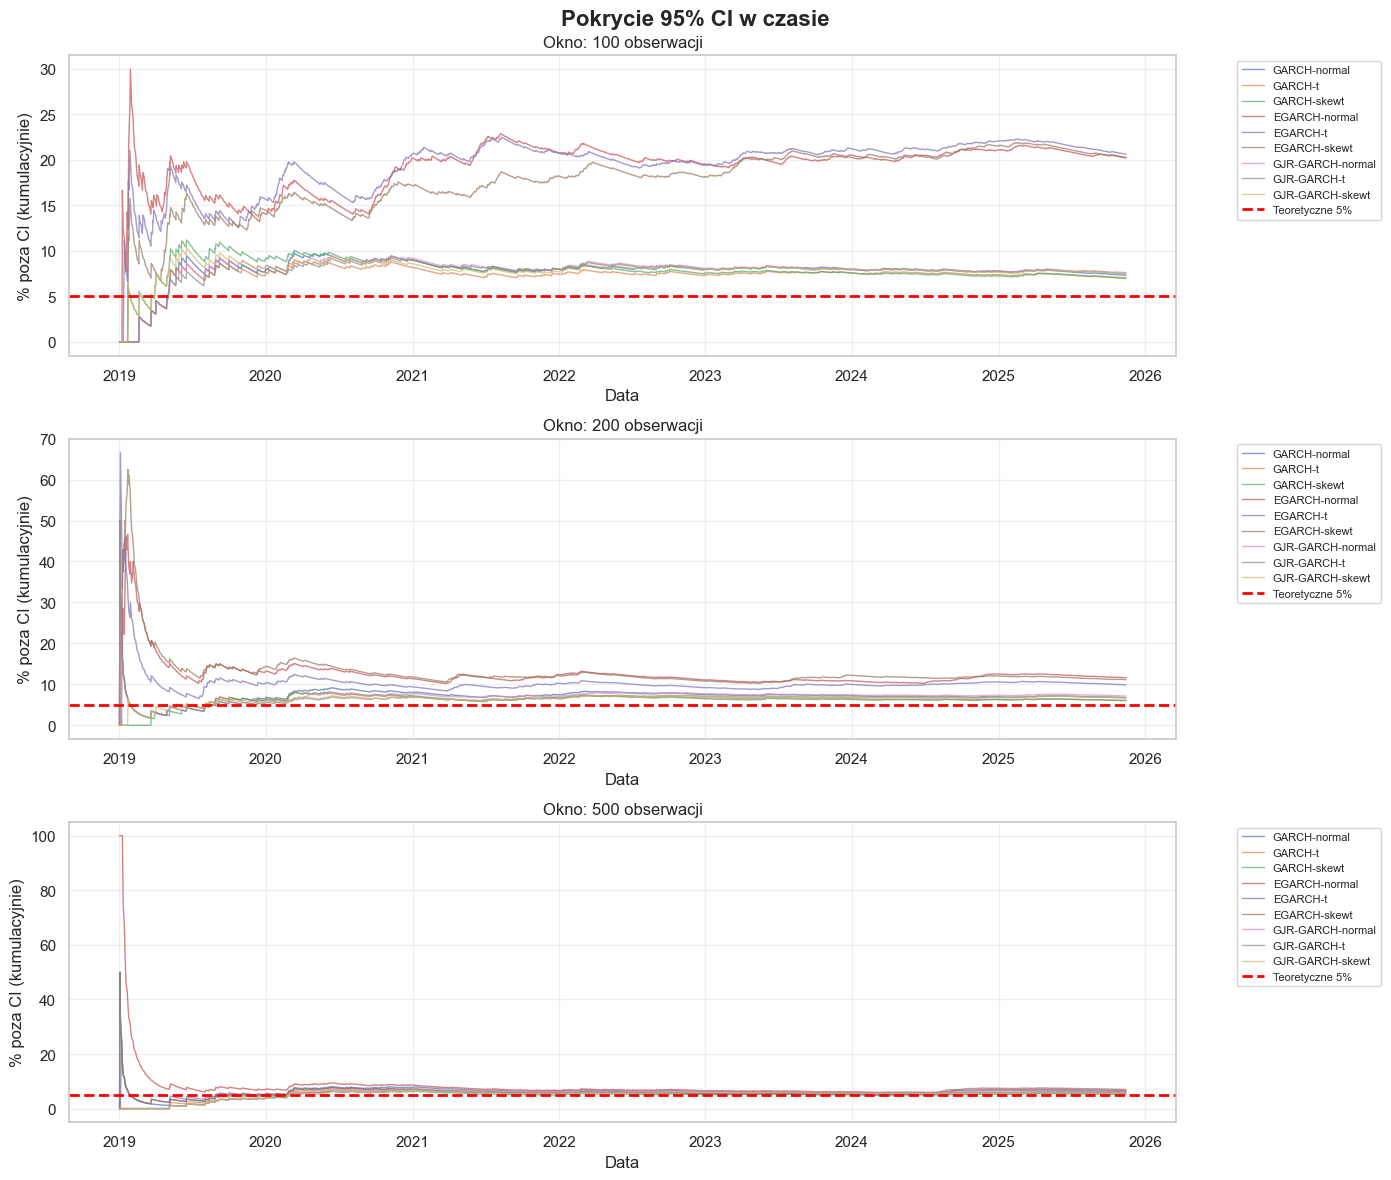

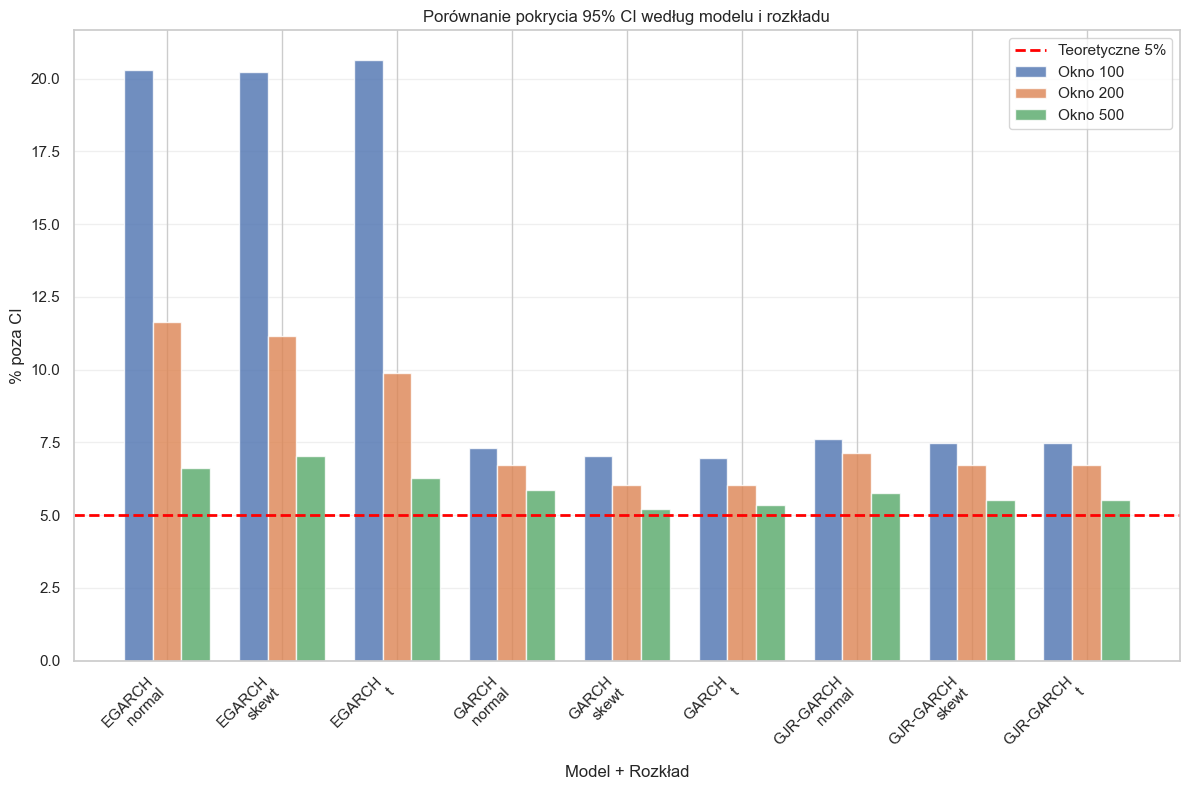

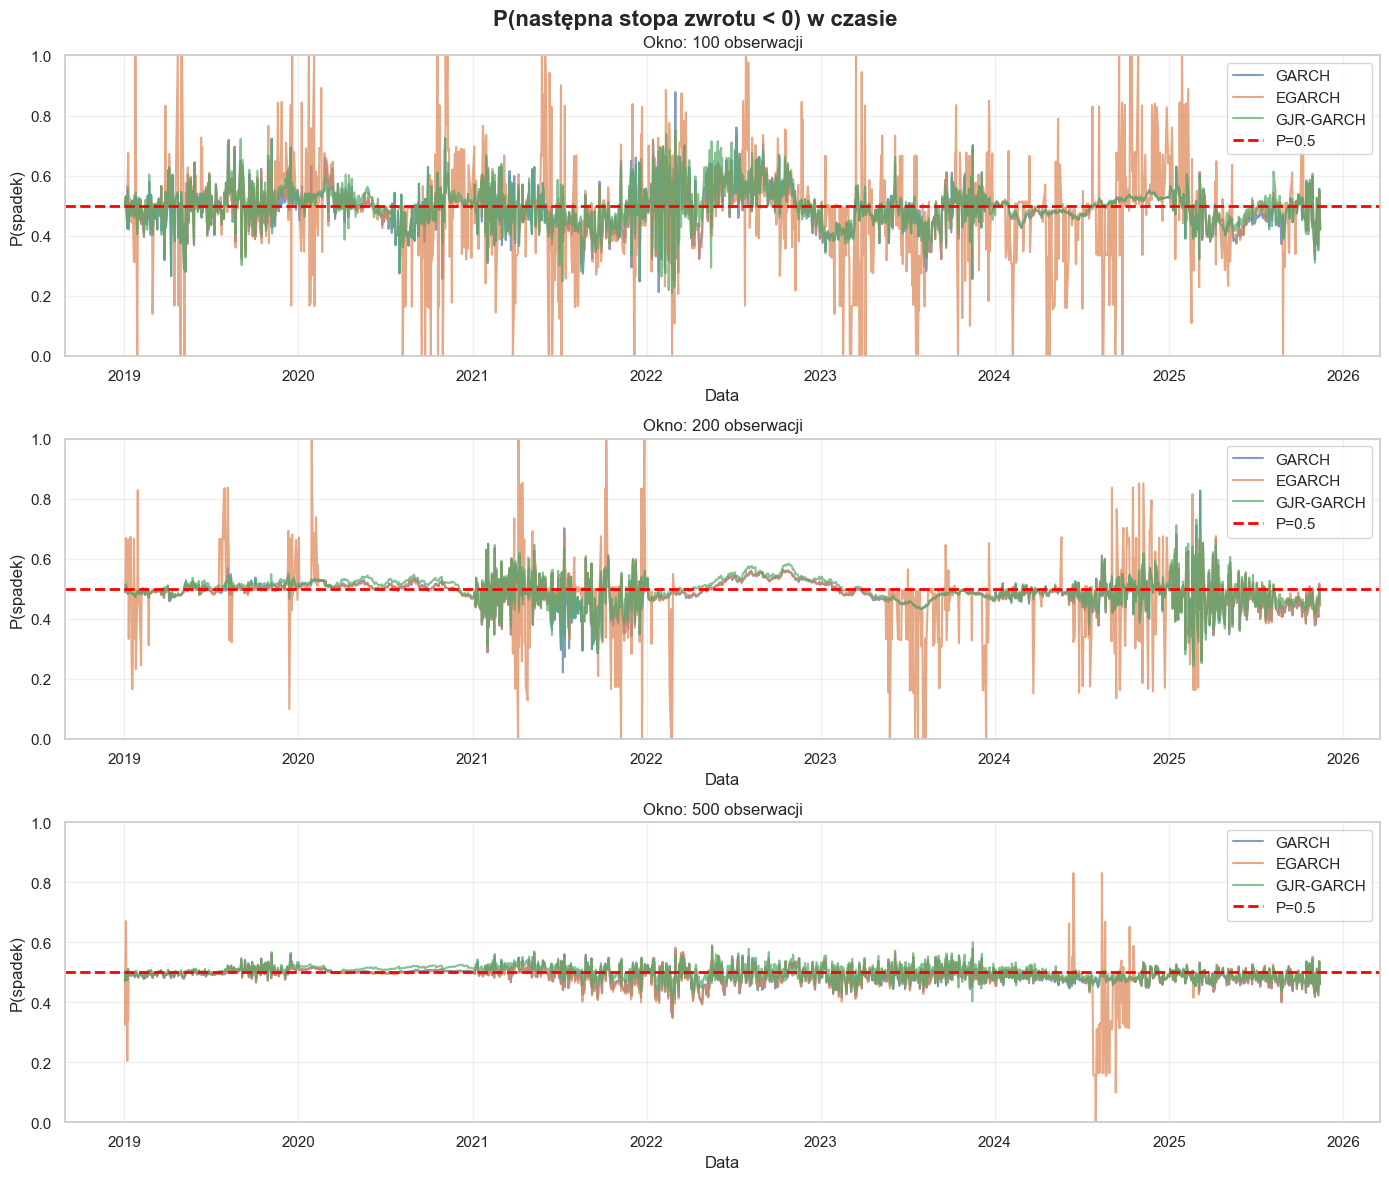

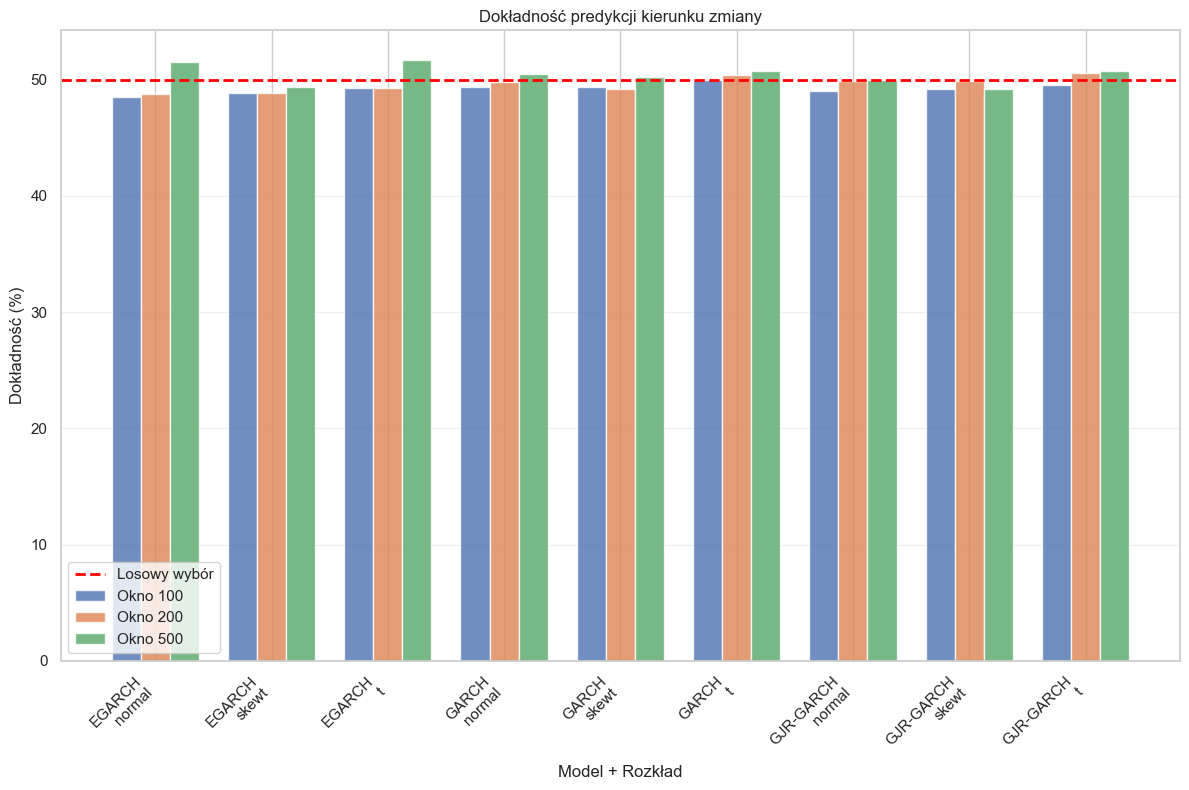

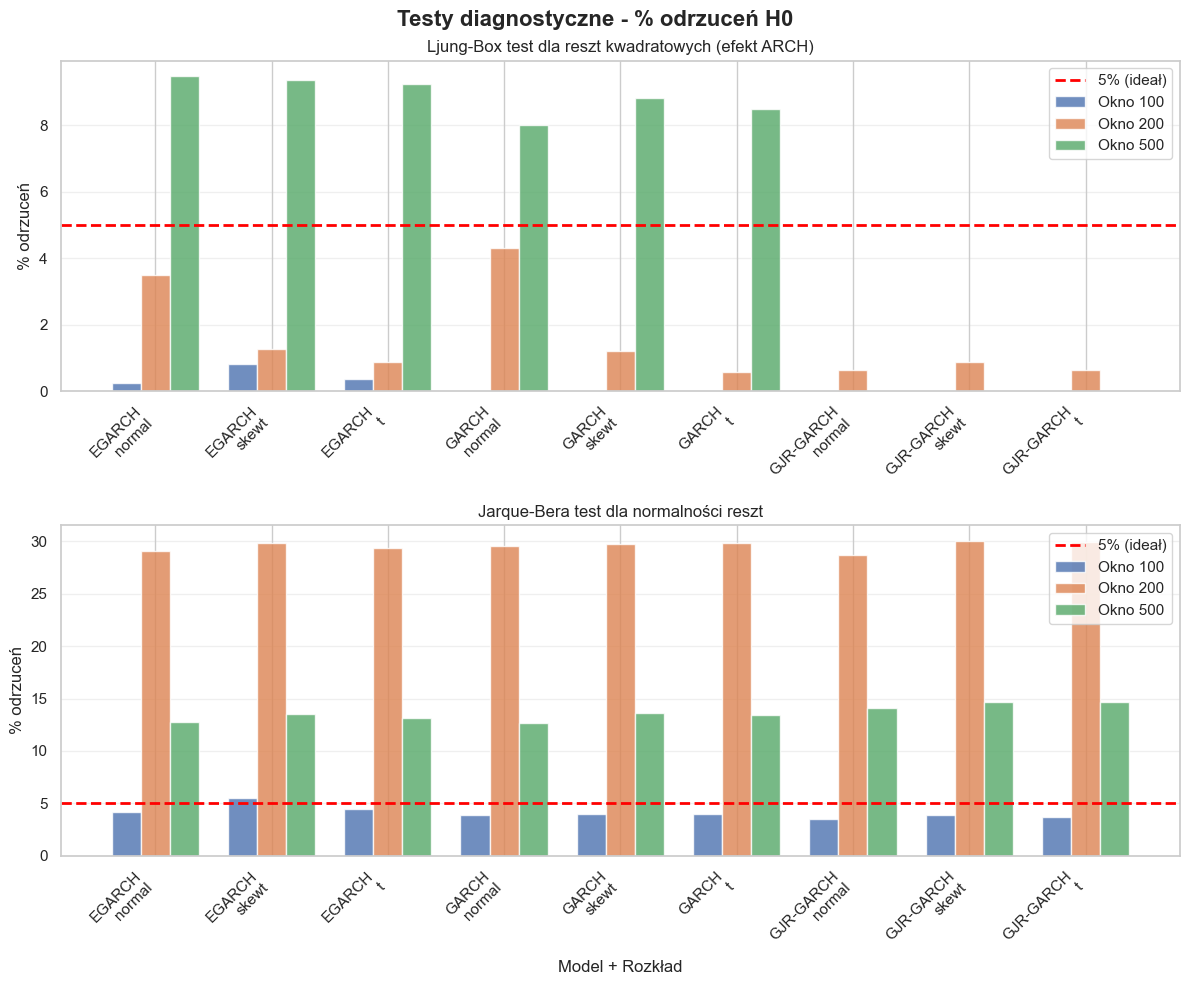

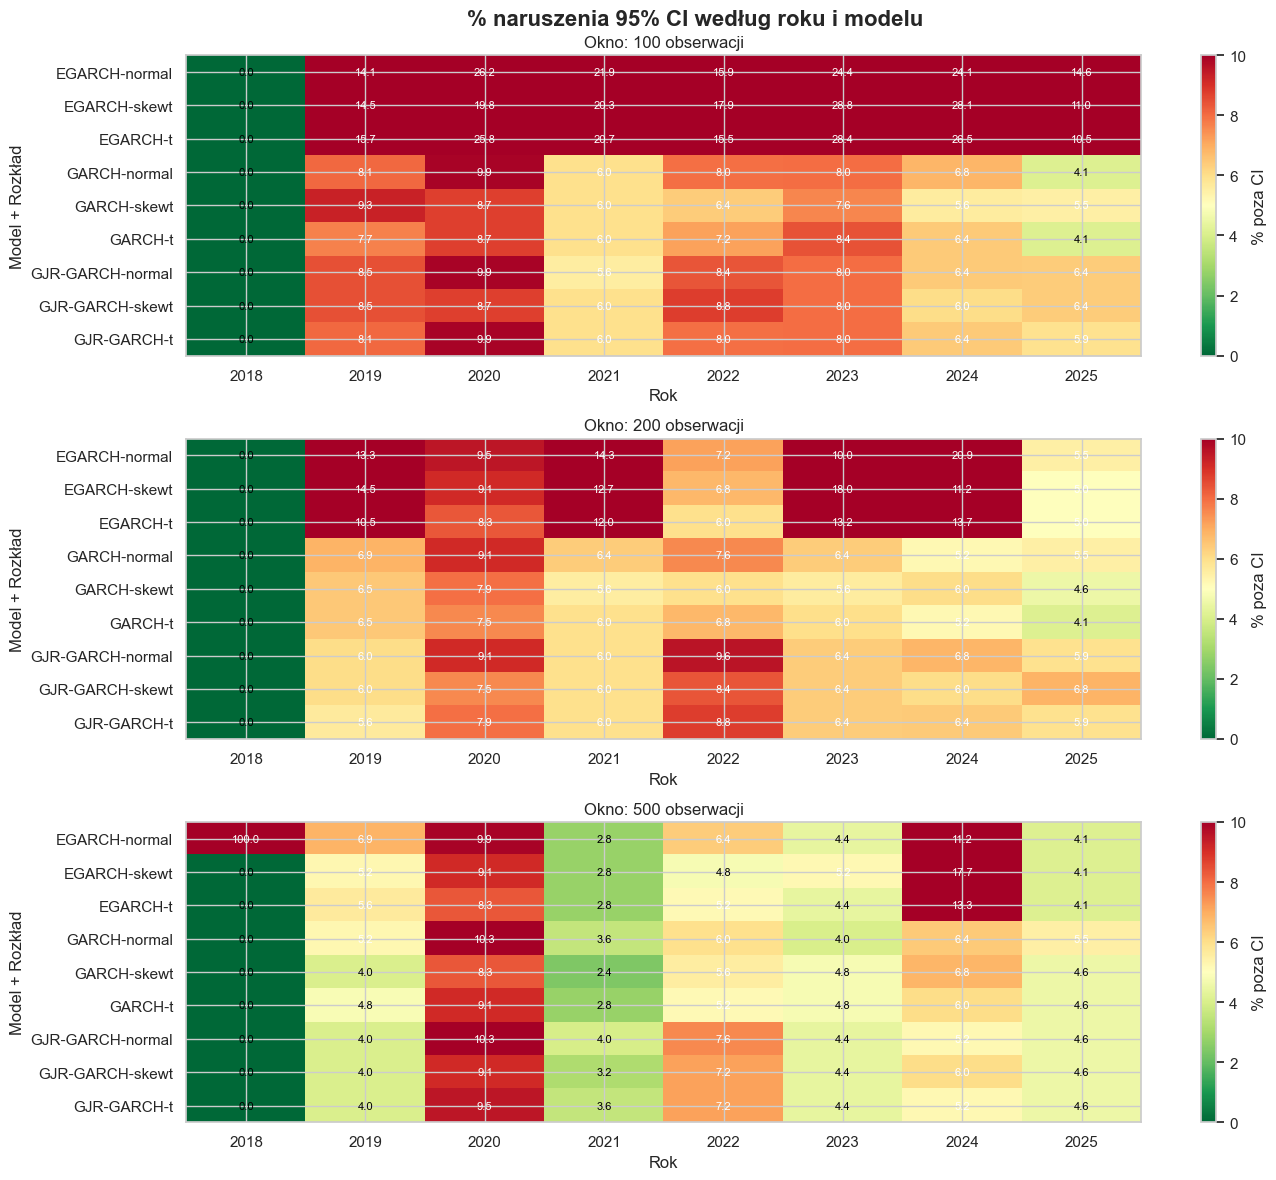


Zapisano dodatkowe statystyki: B_results/forecast_statistics.csv

ANALIZA ZAKOŃCZONA

Wszystkie wyniki dostępne w folderze B_results/:
  - rolling_window_results.csv (szczegółowe wyniki wszystkich prognoz)
  - arma_selections_by_year.csv (wybrane modele ARMA według roku)
  - ci_coverage_analysis.csv (analiza pokrycia CI)
  - ci_violations_by_year.csv (naruszenia CI w czasie)
  - model_distribution_impact.csv (wpływ modelu i rozkładu)
  - residual_diagnostics.csv (diagnostyka reszt)
  - temporal_diagnostics.csv (diagnostyka w czasie)
  - probability_negative_analysis.csv (analiza P(spadek))
  - temporal_probability_analysis.csv (P(spadek) w czasie)
  - high_probability_cases.csv (przypadki P > 0.5)
  - high_probability_temporal.csv (P > 0.5 w czasie)
  - forecast_statistics.csv (statystyki prognoz)
  - analysis_plots.pdf (wykresy i wizualizacje)


In [ ]:
# ============================================================================
# WIZUALIZACJE
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("\n\nGenerowanie wizualizacji...")

# Tworzenie wielostronicowego PDF z wykresami
# Wykres 1: Pokrycie CI w czasie według rozmiaru okna
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Pokrycie 95% CI w czasie', fontsize=16, fontweight='bold')

for idx, window_size in enumerate(WINDOW_SIZES):
    ax = axes[idx]
    window_data = results_df[results_df['window_size'] == window_size]

    for vol_model in vol_models.keys():
        for dist in dists.keys():
            subset = window_data[(window_data['vol_model'] == vol_model) &
                                (window_data['dist'] == dist)]
            if len(subset) > 0:
                # Kumulacyjny odsetek poza CI
                subset = subset.sort_values('forecast_date')
                cumul_outside = (~subset['in_ci']).cumsum() / range(1, len(subset)+1) * 100
                ax.plot(subset['forecast_date'], cumul_outside,
                        label=f"{vol_model}-{dist}", alpha=0.7, linewidth=1)

    ax.axhline(y=5, color='red', linestyle='--', label='Teoretyczne 5%', linewidth=2)
    ax.set_xlabel('Data')
    ax.set_ylabel('% poza CI (kumulacyjnie)')
    ax.set_title(f'Okno: {window_size} obserwacji')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()
plt.close()

# Wykres 2: Porównanie modeli - pokrycie CI
fig, ax = plt.subplots(figsize=(12, 8))

pivot_coverage = ci_df.pivot_table(
    index=['vol_model', 'dist'],
    columns='window_size',
    values='pct_outside_ci'
)

x = np.arange(len(pivot_coverage))
width = 0.25

for i, window_size in enumerate(WINDOW_SIZES):
    if window_size in pivot_coverage.columns:
        ax.bar(x + i*width, pivot_coverage[window_size], width,
                label=f'Okno {window_size}', alpha=0.8)

ax.axhline(y=5, color='red', linestyle='--', label='Teoretyczne 5%', linewidth=2)
ax.set_xlabel('Model + Rozkład')
ax.set_ylabel('% poza CI')
ax.set_title('Porównanie pokrycia 95% CI według modelu i rozkładu')
ax.set_xticks(x + width)
ax.set_xticklabels([f"{m}\n{d}" for m, d in pivot_coverage.index], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
plt.close()

# Wykres 3: P(spadek) w czasie
fig, axes = plt.subplots(len(WINDOW_SIZES), 1, figsize=(14, 12))
fig.suptitle('P(następna stopa zwrotu < 0) w czasie', fontsize=16, fontweight='bold')

for idx, window_size in enumerate(WINDOW_SIZES):
    ax = axes[idx] if len(WINDOW_SIZES) > 1 else axes
    window_data = results_df[results_df['window_size'] == window_size]

    # Średnie P(neg) dla każdego modelu/rozkładu
    for vol_model in ['GARCH', 'EGARCH', 'GJR-GARCH']:
        subset = window_data[window_data['vol_model'] == vol_model]
        if len(subset) > 0:
            # Grupuj według daty i licz średnią
            daily_avg = subset.groupby('forecast_date')['p_neg'].mean()
            ax.plot(daily_avg.index, daily_avg.values,
                    label=vol_model, alpha=0.7, linewidth=1.5)

    ax.axhline(y=0.5, color='red', linestyle='--', label='P=0.5', linewidth=2)
    ax.set_xlabel('Data')
    ax.set_ylabel('P(spadek)')
    ax.set_title(f'Okno: {window_size} obserwacji')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()
plt.close()

# Wykres 4: Dokładność predykcji kierunku
fig, ax = plt.subplots(figsize=(12, 8))

pivot_accuracy = prob_df.pivot_table(
    index=['vol_model', 'dist'],
    columns='window_size',
    values='overall_accuracy'
)

x = np.arange(len(pivot_accuracy))
width = 0.25

for i, window_size in enumerate(WINDOW_SIZES):
    if window_size in pivot_accuracy.columns:
        ax.bar(x + i*width, pivot_accuracy[window_size], width,
                label=f'Okno {window_size}', alpha=0.8)

ax.axhline(y=50, color='red', linestyle='--', label='Losowy wybór', linewidth=2)
ax.set_xlabel('Model + Rozkład')
ax.set_ylabel('Dokładność (%)')
ax.set_title('Dokładność predykcji kierunku zmiany')
ax.set_xticks(x + width)
ax.set_xticklabels([f"{m}\n{d}" for m, d in pivot_accuracy.index], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
plt.close()

# Wykres 5: Testy diagnostyczne (JB, LB)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Testy diagnostyczne - % odrzuceń H0', fontsize=16, fontweight='bold')

# Ljung-Box dla reszt kwadratowych
ax = axes[0]
pivot_lb = diag_df.pivot_table(
    index=['vol_model', 'dist'],
    columns='window_size',
    values='pct_lb_sqresid_reject'
)

x = np.arange(len(pivot_lb))
width = 0.25

for i, window_size in enumerate(WINDOW_SIZES):
    if window_size in pivot_lb.columns:
        ax.bar(x + i*width, pivot_lb[window_size], width,
                label=f'Okno {window_size}', alpha=0.8)

ax.axhline(y=5, color='red', linestyle='--', label='5% (ideał)', linewidth=2)
ax.set_ylabel('% odrzuceń')
ax.set_title('Ljung-Box test dla reszt kwadratowych (efekt ARCH)')
ax.set_xticks(x + width)
ax.set_xticklabels([f"{m}\n{d}" for m, d in pivot_lb.index], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Jarque-Bera dla normalności
ax = axes[1]
pivot_jb = diag_df.pivot_table(
    index=['vol_model', 'dist'],
    columns='window_size',
    values='pct_jb_reject'
)

for i, window_size in enumerate(WINDOW_SIZES):
    if window_size in pivot_jb.columns:
        ax.bar(x + i*width, pivot_jb[window_size], width,
                label=f'Okno {window_size}', alpha=0.8)

ax.axhline(y=5, color='red', linestyle='--', label='5% (ideał)', linewidth=2)
ax.set_xlabel('Model + Rozkład')
ax.set_ylabel('% odrzuceń')
ax.set_title('Jarque-Bera test dla normalności reszt')
ax.set_xticks(x + width)
ax.set_xticklabels([f"{m}\n{d}" for m, d in pivot_jb.index], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close()

# Wykres 6: Heatmapa - naruszenia CI według roku i modelu
fig, axes = plt.subplots(len(WINDOW_SIZES), 1, figsize=(14, 12))
fig.suptitle('% naruszenia 95% CI według roku i modelu', fontsize=16, fontweight='bold')

for idx, window_size in enumerate(WINDOW_SIZES):
    ax = axes[idx] if len(WINDOW_SIZES) > 1 else axes
    window_data = results_df[results_df['window_size'] == window_size]

    pivot_yearly = window_data.pivot_table(
        index=['vol_model', 'dist'],
        columns='year',
        values='in_ci',
        aggfunc=lambda x: 100 * (1 - x.mean())
    )

    if len(pivot_yearly) > 0:
        im = ax.imshow(pivot_yearly.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=10)
        ax.set_yticks(range(len(pivot_yearly)))
        ax.set_yticklabels([f"{m}-{d}" for m, d in pivot_yearly.index])
        ax.set_xticks(range(len(pivot_yearly.columns)))
        ax.set_xticklabels(pivot_yearly.columns)
        ax.set_xlabel('Rok')
        ax.set_ylabel('Model + Rozkład')
        ax.set_title(f'Okno: {window_size} obserwacji')

        # Dodaj wartości do komórek
        for i in range(len(pivot_yearly)):
            for j in range(len(pivot_yearly.columns)):
                val = pivot_yearly.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                            color='white' if val > 5 else 'black', fontsize=8)

        plt.colorbar(im, ax=ax, label='% poza CI')

plt.tight_layout()
plt.show()
plt.close()


# ============================================================================
# EKSPORT DODATKOWYCH STATYSTYK
# ============================================================================

# Statystyki opisowe prognoz
forecast_stats = results_df.groupby(['window_size', 'vol_model', 'dist']).agg({
    'cond_mean': ['mean', 'std', 'min', 'max'],
    'cond_std': ['mean', 'std', 'min', 'max'],
    'real_next': ['mean', 'std'],
    'aic': 'mean',
    'bic': 'mean'
}).round(4)
forecast_stats.columns = ['_'.join(col).strip() for col in forecast_stats.columns.values]
forecast_stats = forecast_stats.reset_index()
forecast_stats.to_csv("B_results/forecast_statistics.csv", index=False)

print("\nZapisano dodatkowe statystyki: B_results/forecast_statistics.csv")

print("\n" + "="*80)
print("ANALIZA ZAKOŃCZONA")
print("="*80)
print("\nWszystkie wyniki dostępne w folderze B_results/:")
print("  - rolling_window_results.csv (szczegółowe wyniki wszystkich prognoz)")
print("  - arma_selections_by_year.csv (wybrane modele ARMA według roku)")
print("  - ci_coverage_analysis.csv (analiza pokrycia CI)")
print("  - ci_violations_by_year.csv (naruszenia CI w czasie)")
print("  - model_distribution_impact.csv (wpływ modelu i rozkładu)")
print("  - residual_diagnostics.csv (diagnostyka reszt)")
print("  - temporal_diagnostics.csv (diagnostyka w czasie)")
print("  - probability_negative_analysis.csv (analiza P(spadek))")
print("  - temporal_probability_analysis.csv (P(spadek) w czasie)")
print("  - high_probability_cases.csv (przypadki P > 0.5)")
print("  - high_probability_temporal.csv (P > 0.5 w czasie)")
print("  - forecast_statistics.csv (statystyki prognoz)")
print("  - analysis_plots.pdf (wykresy i wizualizacje)")
print("="*80)

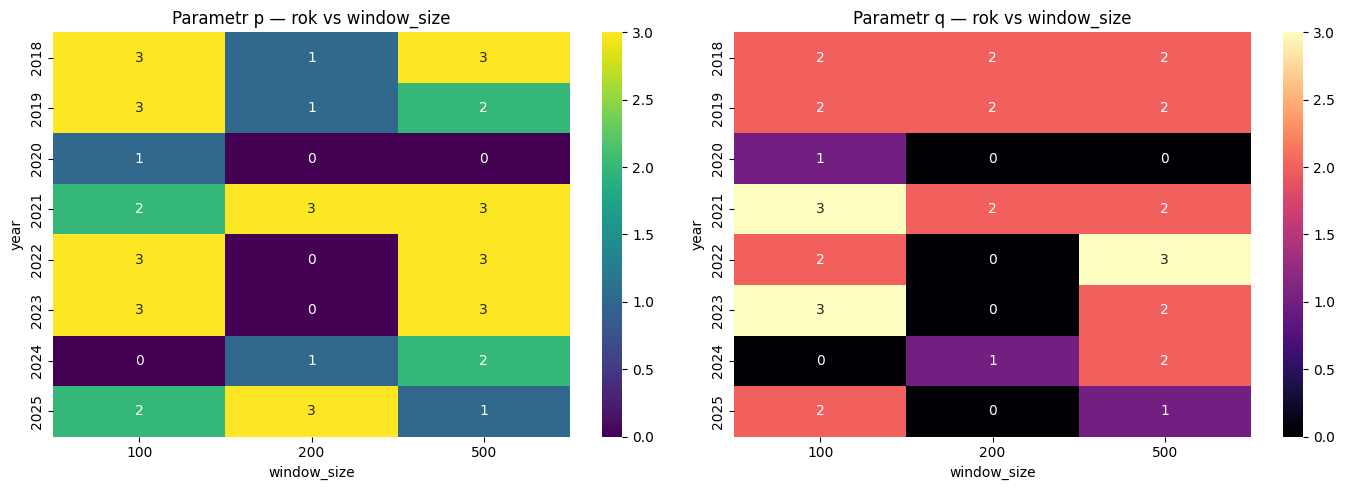

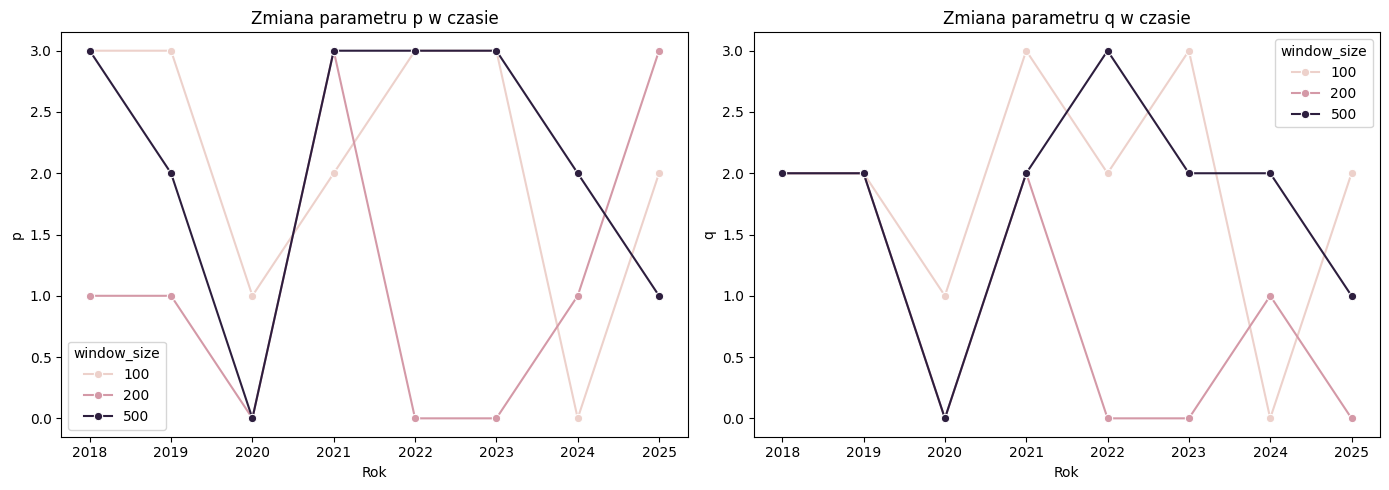

In [ ]:
#Wykresy do wyboru modelu ARMA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("arma_selections_by_year.csv")

pivot_p = df.pivot(index="year", columns="window_size", values="p")
pivot_q = df.pivot(index="year", columns="window_size", values="q")

plt.figure(figsize=(14,5))

# Heatmap p
plt.subplot(1, 2, 1)
sns.heatmap(pivot_p, annot=True, cmap="viridis")
plt.title("Parametr p — rok vs window_size")

# Heatmap q
plt.subplot(1, 2, 2)
sns.heatmap(pivot_q, annot=True, cmap="magma")
plt.title("Parametr q — rok vs window_size")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14,5))

# Wykres p
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x="year", y="p", hue="window_size", marker="o")
plt.title("Zmiana parametru p w czasie")
plt.xlabel("Rok")
plt.ylabel("p")

# Wykres q
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x="year", y="q", hue="window_size", marker="o")
plt.title("Zmiana parametru q w czasie")
plt.xlabel("Rok")
plt.ylabel("q")

plt.tight_layout()
plt.show()



In [ ]:
# Obróbka pliku rolling_window_results żeby wybrać jakieś ładne modele GARCH

import pandas as pd

# Wczytanie danych
df = pd.read_csv("rolling_window_results.csv")

# Sprawdzenie, że potrzebne kolumny istnieją (opcjonalne)
required_cols = {"window_size", "window_num", "year", "vol_model", "dist", "arma_p", "arma_q", "aic", "bic"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Brakuje kolumn w pliku wejściowym: {missing}")

# Sortujemy po aic rosnąco, a jako drugi kryterium po bic (również rosnąco)
df_sorted = df.sort_values(by=["window_size", "window_num", "aic", "bic"], ascending=[True, True, True, True])

# Dla każdej kombinacji window_size + window_num bierzemy pierwszy (najlepszy) wiersz
best = df_sorted.drop_duplicates(subset=["window_size", "window_num"], keep="first")

# Zostawiamy tylko kolumny, które chciałaś w pliku końcowym
best = best[["window_size", "window_num", "year", "vol_model", "dist", "arma_p", "arma_q", "aic", "bic"]]

# Zapis do pliku wynikowego
best.to_csv("best_models_by_window.csv", index=False)

print("Zapisano plik 'best_models_by_window.csv' z 1 najlepszym modelem na każde okno i window_size.")


Zapisano plik 'best_models_by_window.csv' z 1 najlepszym modelem na każde okno i window_size.


C:\Users\hp\AppData\Local\Temp\ipykernel_11252\1830786871.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = subset.groupby(["window_size", "model_dist"]).size().reset_index(name="count")
C:\Users\hp\AppData\Local\Temp\ipykernel_11252\1830786871.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = subset.groupby(["window_size", "model_dist"]).size().reset_index(name="count")
C:\Users\hp\AppData\Local\Temp\ipykernel_11252\1830786871.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

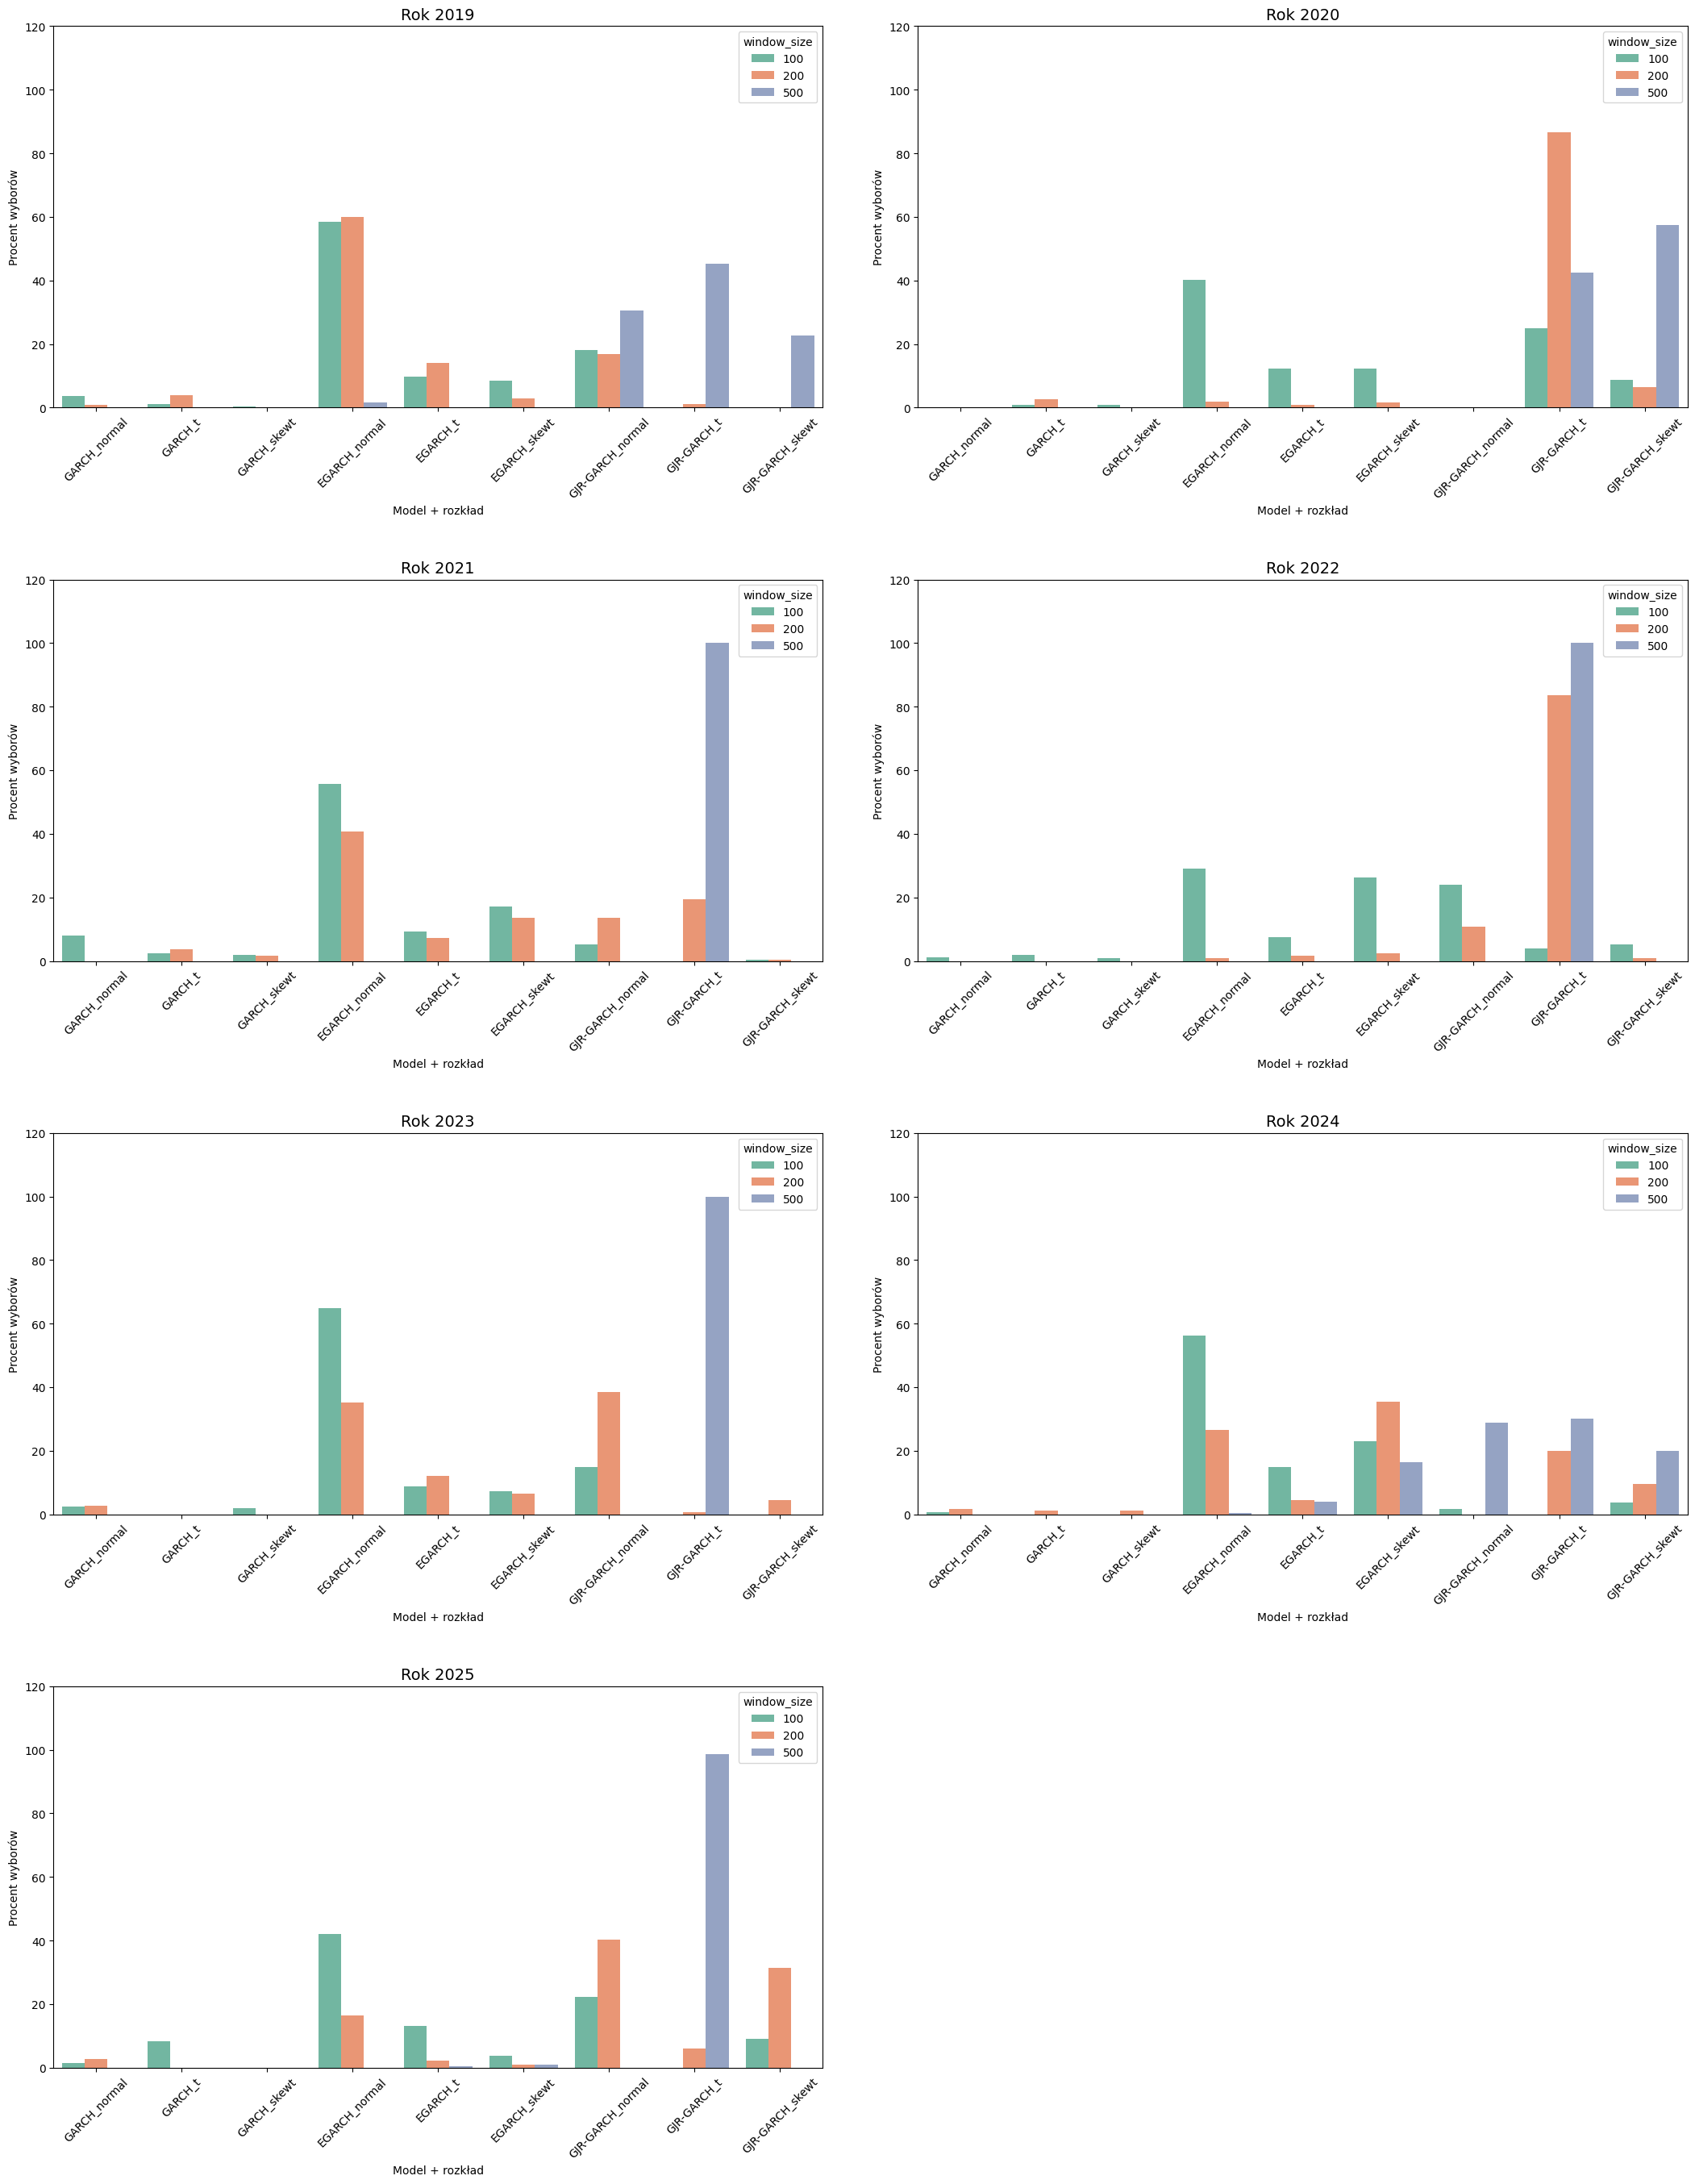

In [ ]:
#Wykresy dla wyboru modelu GARCH

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
df = pd.read_csv("best_models_by_window.csv")

# Utworzenie kolumny łączącej vol_model + dist
df["model_dist"] = df["vol_model"] + "_" + df["dist"]

# Upewniamy się, że kategorie są w ustalonej kolejności (dla osi X)
order = [
    "GARCH_normal", "GARCH_t", "GARCH_skewt",
    "EGARCH_normal", "EGARCH_t", "EGARCH_skewt",
    "GJR-GARCH_normal", "GJR-GARCH_t", "GJR-GARCH_skewt"
]
df["model_dist"] = pd.Categorical(df["model_dist"], categories=order, ordered=True)

# Lista lat do analizy
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Tworzymy siatkę subplotów
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(22, 28))

# Spłaszczamy tablicę axes do listy dla łatwego iterowania
axes = axes.flatten()

for i, year in enumerate(years):
    subset = df[df["year"] == year]

    counts = subset.groupby(["window_size", "model_dist"]).size().reset_index(name="count")
    counts["percent"] = counts.groupby("window_size")["count"].transform(lambda x: 100 * x / x.sum())

    sns.barplot(
        data=counts,
        x="model_dist",
        y="percent",
        hue="window_size",
        palette=["#66c2a5", "#fc8d62", "#8da0cb"],
        ax=axes[i]
    )

    axes[i].set_title(f"Rok {year}", fontsize=14)
    axes[i].set_ylim(0, 120)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Procent wyborów")
    axes[i].set_xlabel("Model + rozkład")
    axes[i].legend(title="window_size")

for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# Poprawiamy odstępy między subplotami
plt.tight_layout(pad=4)  # pad=4 zwiększa odstęp między rzędami i kolumnami
plt.show()


In [ ]:
#Zbiorcza tabela wyników dopasowania modelu GARCH
import pandas as pd

# Wczytanie danych
df = pd.read_csv("best_models_by_window.csv")

# Tworzymy kolumnę model + dist
df["model_dist"] = df["vol_model"] + "_" + df["dist"]

# Lista lat i okien
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
window_sizes = [100, 200, 500]

# Tworzymy pusty DataFrame do wyników
table = pd.DataFrame(index=window_sizes, columns=years)

# Wypełniamy tabelę najczęściej wybieranym modelem
for year in years:
    for window in window_sizes:
        subset = df[(df["year"] == year) & (df["window_size"] == window)]
        if not subset.empty:
            # Najczęściej wybierany model
            top_model = subset["model_dist"].value_counts().idxmax()
            table.loc[window, year] = top_model
        else:
            table.loc[window, year] = None  # brak danych

# Zapis do Excela
table.to_excel("najczesciej_wybierany_model.xlsx")

print("Tabela zapisana do pliku 'najczesciej_wybierany_model.xlsx'")


Tabela zapisana do pliku 'najczesciej_wybierany_model.xlsx'
